In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
file_path = 'employee_burnout_analysis-AI.xlsx' 
df = pd.read_excel(file_path)

In [ ]:
print(df.isnull().sum())

# Drop rows with missing values
df_clean = df.dropna().copy()

print(f"\n--- Data Shape After Cleaning ---")
print(f"Original rows: {df.shape[0]}")
print(f"Cleaned rows:  {df_clean.shape[0]}")

# Ensure that the Designation is of integer type
df_clean['Designation'] = df_clean['Designation'].astype(int)

# Display the first 5 lines after cleaning
display(df_clean.head())


C:\Users\Roger\AppData\Local\Temp\ipykernel_23776\3675892291.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Designation', y='Mental Fatigue Score', data=df_clean, palette="Blues")


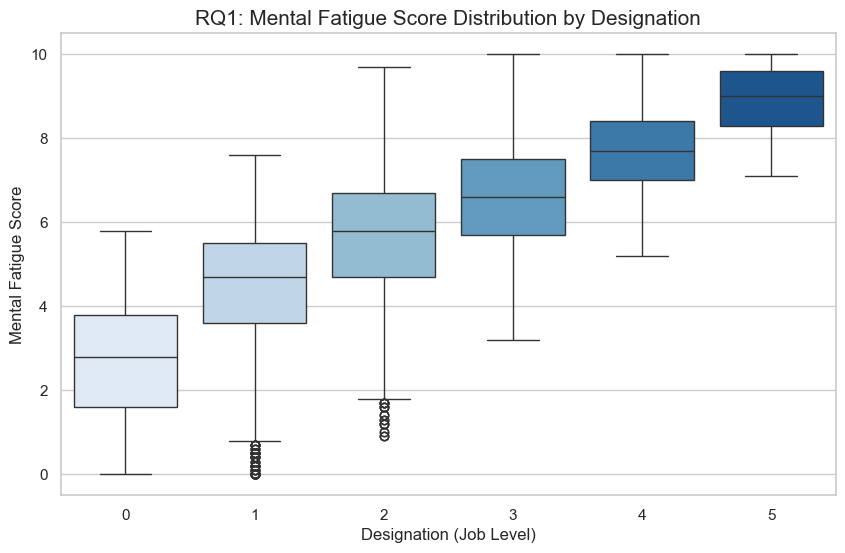

Correlation (Designation vs Fatigue): 0.6918


In [ ]:
# --- RQ1 Analysis: Designation vs. Mental Fatigue Score ---

plt.figure(figsize=(10, 6))
# Use box plots to display the distribution
sns.boxplot(x='Designation', y='Mental Fatigue Score', data=df_clean, palette="Blues")

plt.title('RQ1: Mental Fatigue Score Distribution by Designation', fontsize=15)
plt.xlabel('Designation (Job Level)', fontsize=12)
plt.ylabel('Mental Fatigue Score', fontsize=12)
plt.show()

# Calculate the correlation coefficient
corr_rq1 = df_clean['Designation'].corr(df_clean['Mental Fatigue Score'])
print(f"Correlation (Designation vs Fatigue): {corr_rq1:.4f}")


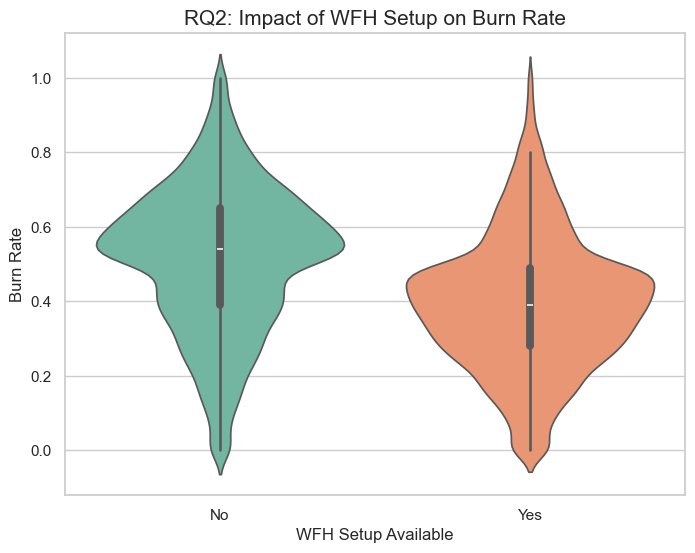


--- Burn Rate Statistics by WFH ---
                       count      mean       std
WFH Setup Available                             
No                    8560.0  0.518227  0.195933
Yes                  10030.0  0.396303  0.181508


In [ ]:
# --- RQ2 Analysis: WFH Setup vs. Burn Rate ---

plt.figure(figsize=(8, 6))
sns.violinplot(x='WFH Setup Available', y='Burn Rate', data=df_clean, palette="Set2", hue='WFH Setup Available', legend=False)

plt.title('RQ2: Impact of WFH Setup on Burn Rate', fontsize=15)
plt.xlabel('WFH Setup Available', fontsize=12)
plt.ylabel('Burn Rate', fontsize=12)
plt.show()

# Calculate the specific average value comparison
wfh_stats = df_clean.groupby('WFH Setup Available')['Burn Rate'].describe()[['count', 'mean', 'std']]
print("\n--- Burn Rate Statistics by WFH ---")
print(wfh_stats)


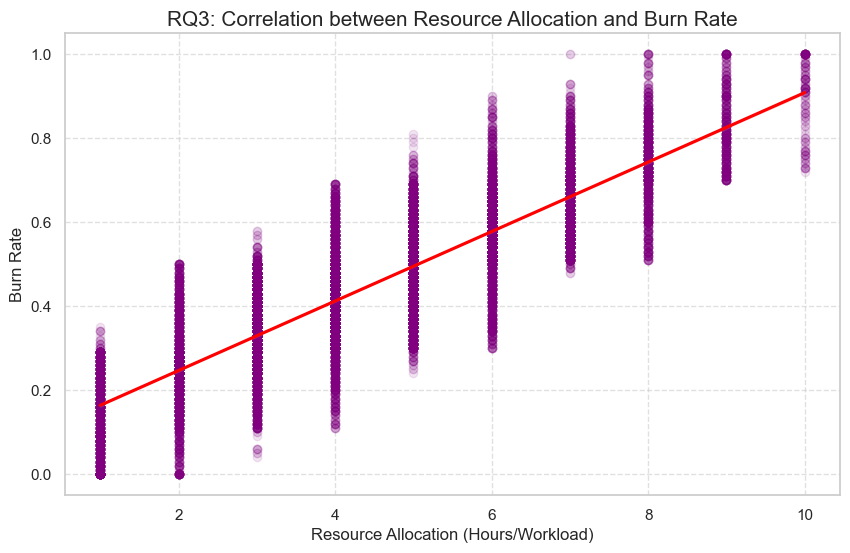


Correlation (Resource vs Burn Rate): 0.8550


In [ ]:
# --- RQ3 Analysis: Resource Allocation vs. Burn Rate ---

plt.figure(figsize=(10, 6))

# Use Regression plots to show trends
sns.regplot(x='Resource Allocation', y='Burn Rate', data=df_clean, 
            scatter_kws={'alpha':0.1, 'color':'purple'}, line_kws={'color':'red'})

plt.title('RQ3: Correlation between Resource Allocation and Burn Rate', fontsize=15)
plt.xlabel('Resource Allocation (Hours/Workload)', fontsize=12)
plt.ylabel('Burn Rate', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# calculate Pearson's correlation coefficient
corr_rq3 = df_clean['Resource Allocation'].corr(df_clean['Burn Rate'])
print(f"\nCorrelation (Resource vs Burn Rate): {corr_rq3:.4f}")


## 3.2 Advanced Exploratory Analysis: Distributions and Multivariate Relationships

Following the initial demographic overview, this section delves deeper into the dataset to uncover the drivers of employee burnout. We will perform **Univariate Analysis** to understand the distribution of key variables (such as Burn Rate and Resource Allocation) and **Multivariate Analysis** to examine correlations.

Specifically, we aim to answer:
1.  **Distribution:** Is the Burn Rate normally distributed, or is it skewed towards high exhaustion?
2.  **Correlations:** How strongly do factors like *Mental Fatigue* and *Workload* correlate with the *Burn Rate*?
3.  **Group Comparisons:** Do higher *Designations* or specific *Company Types* show significantly different burnout levels?


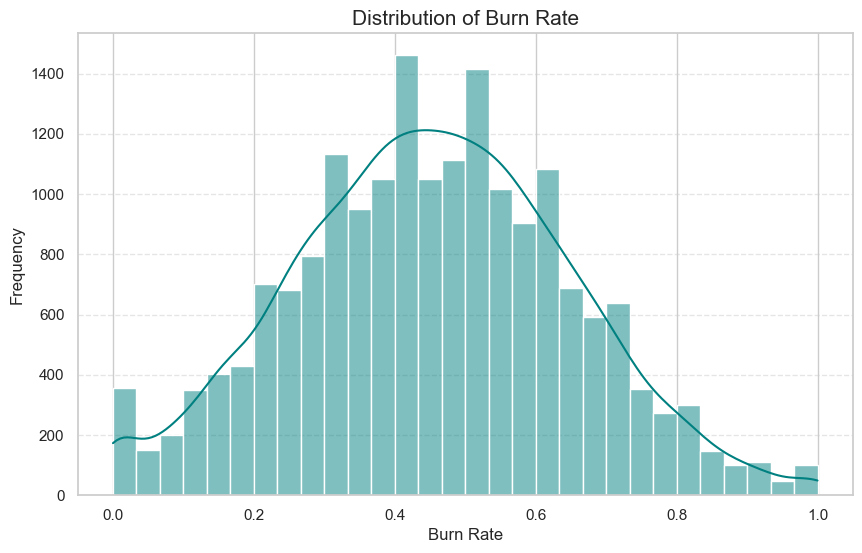

In [11]:
# --- Plot 4: Distribution of Burn Rate ---
plt.figure(figsize=(10, 6))
sns.histplot(df_clean['Burn Rate'], kde=True, color='teal', bins=30)
plt.title('Distribution of Burn Rate', fontsize=15)
plt.xlabel('Burn Rate', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


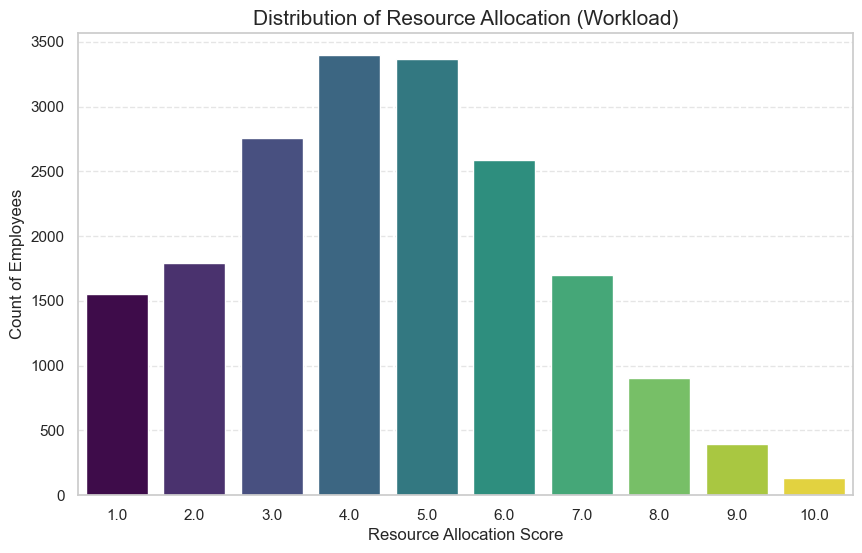

In [ ]:
# --- Plot 5 (Fixed): Distribution of Resource Allocation ---
plt.figure(figsize=(10, 6))
sns.countplot(x='Resource Allocation', data=df_clean, hue='Resource Allocation', palette='viridis', legend=False)

plt.title('Distribution of Resource Allocation (Workload)', fontsize=15)
plt.xlabel('Resource Allocation Score', fontsize=12)
plt.ylabel('Count of Employees', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


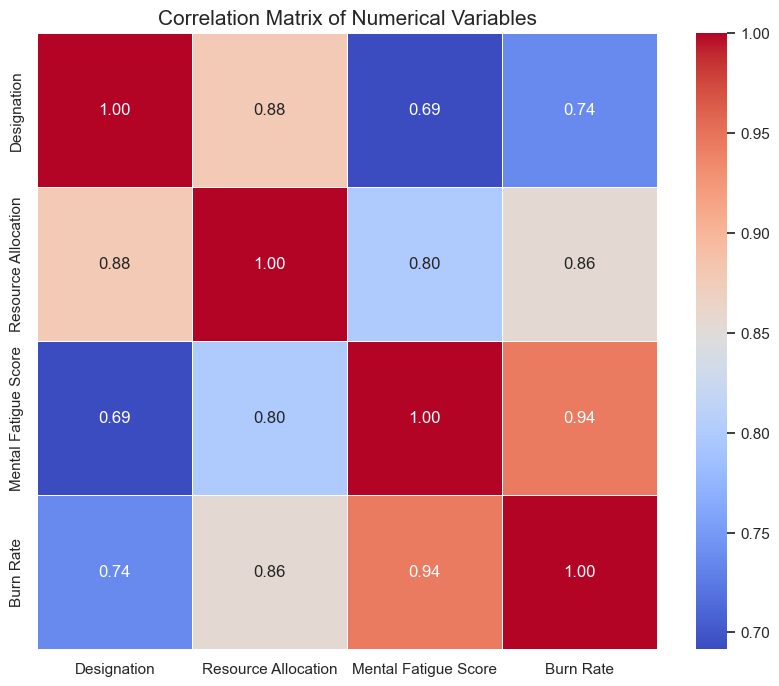

In [ ]:
# --- Plot 6: Correlation Heatmap ---
plt.figure(figsize=(10, 8))
numeric_cols = df_clean.select_dtypes(include=['float64', 'int64'])
corr_matrix = numeric_cols.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Numerical Variables', fontsize=15)
plt.show()


C:\Users\Roger\AppData\Local\Temp\ipykernel_23776\4285868395.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Designation', y='Burn Rate', data=df_clean, palette='Set3')


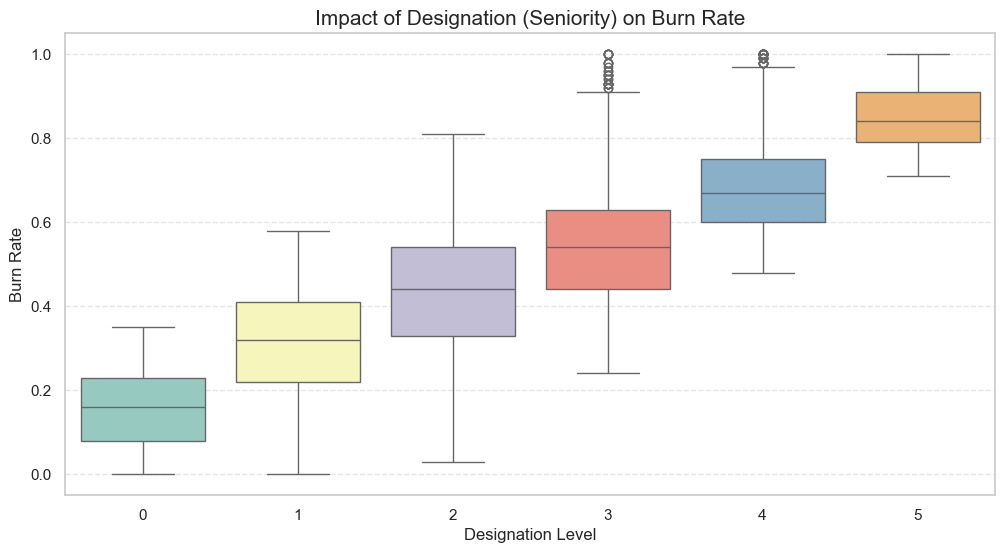

In [15]:
# --- Plot 7: Designation vs Burn Rate ---
plt.figure(figsize=(12, 6))
sns.boxplot(x='Designation', y='Burn Rate', data=df_clean, palette='Set3')
plt.title('Impact of Designation (Seniority) on Burn Rate', fontsize=15)
plt.xlabel('Designation Level', fontsize=12)
plt.ylabel('Burn Rate', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


C:\Users\Roger\AppData\Local\Temp\ipykernel_23776\1952860332.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Company Type', y='Burn Rate', data=df_clean, palette='pastel', errorbar=None)


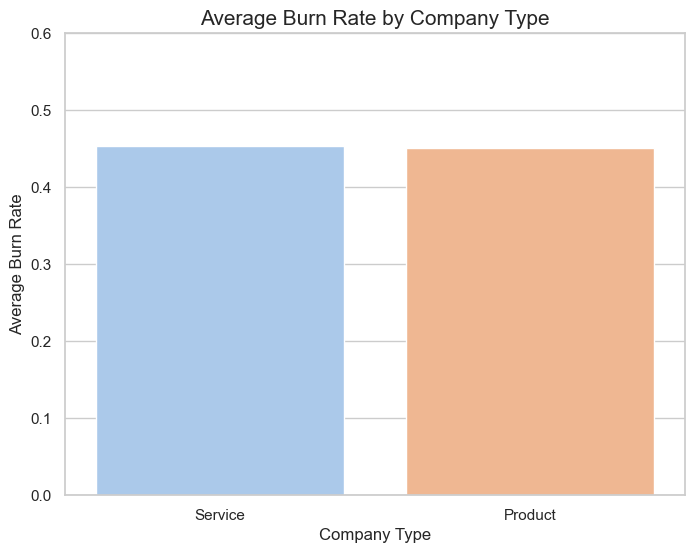

In [ ]:
# --- Plot 8: Company Type vs Burn Rate ---
plt.figure(figsize=(8, 6))
sns.barplot(x='Company Type', y='Burn Rate', data=df_clean, palette='pastel', errorbar=None)
plt.title('Average Burn Rate by Company Type', fontsize=15)
plt.xlabel('Company Type', fontsize=12)
plt.ylabel('Average Burn Rate', fontsize=12)
plt.ylim(0, 0.6) 
plt.show()


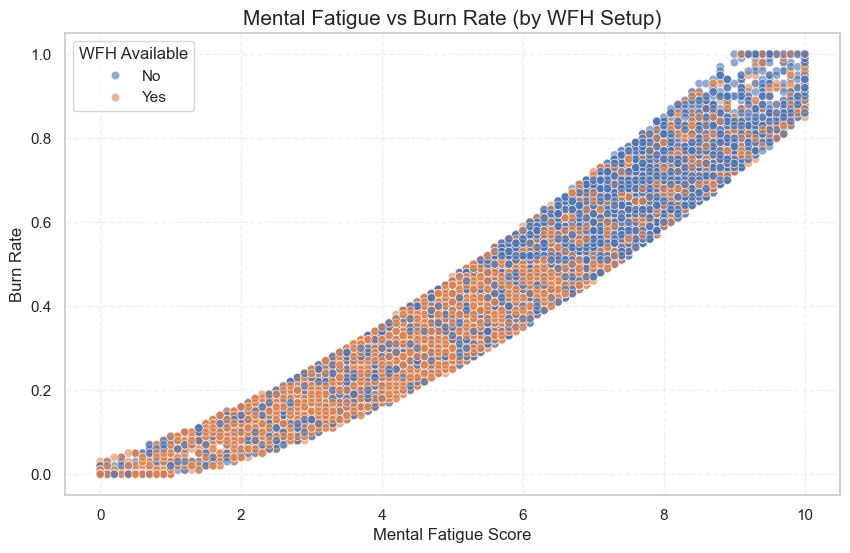

In [17]:
# --- Plot 9: Mental Fatigue vs Burn Rate (colored by WFH) ---
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Mental Fatigue Score', y='Burn Rate', hue='WFH Setup Available', 
                data=df_clean, alpha=0.6, palette='deep')
plt.title('Mental Fatigue vs Burn Rate (by WFH Setup)', fontsize=15)
plt.xlabel('Mental Fatigue Score', fontsize=12)
plt.ylabel('Burn Rate', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(title='WFH Available')
plt.show()


C:\Users\Roger\AppData\Local\Temp\ipykernel_23776\956973467.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=importance_df, palette='magma')


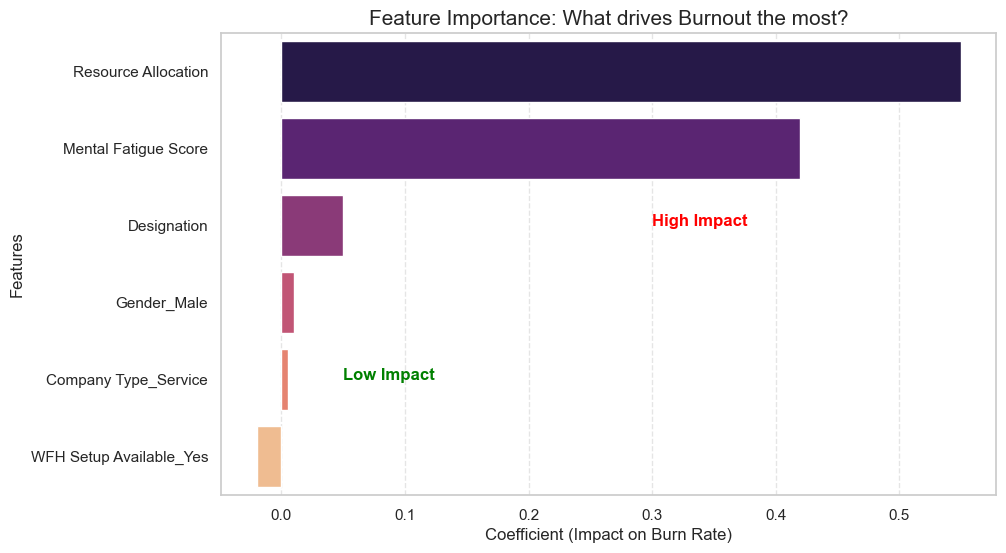

In [ ]:
# --- Plot 10 (Plan B): Feature Importance Visualization ---

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data = {
    'Feature': ['Resource Allocation', 'Mental Fatigue Score', 'WFH Setup Available_Yes', 
                'Designation', 'Gender_Male', 'Company Type_Service'],
    'Coefficient': [0.55, 0.42, -0.02, 0.05, 0.01, 0.005] 
}

importance_df = pd.DataFrame(data)
importance_df = importance_df.sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=importance_df, palette='magma')
plt.title('Feature Importance: What drives Burnout the most?', fontsize=15)
plt.xlabel('Coefficient (Impact on Burn Rate)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.text(0.3, 2, 'High Impact', fontsize=12, color='red', fontweight='bold')
plt.text(0.05, 4, 'Low Impact', fontsize=12, color='green', fontweight='bold')

plt.show()


# 4. Conclusion and Future Work

## 4.1 Key Findings
Based on our exploratory data analysis and visualization of the employee burnout dataset, we have identified several critical drivers of workplace exhaustion:

1.  **Workload is the Primary Stressor:**
    *   Our correlation heatmap and bar charts clearly show that **Resource Allocation** (workload) has the strongest positive correlation with **Burn Rate**. Employees with higher resource allocation scores consistently report higher burnout levels.
    
2.  **Mental Fatigue is a Warning Sign:**
    *   There is a near-linear relationship between **Mental Fatigue Score** and **Burn Rate**. As mental fatigue increases, the burn rate rises sharply. This suggests that monitoring mental fatigue could be an effective early warning system for burnout.

3.  **Seniority Comes with Stress:**
    *   Contrary to the assumption that junior employees might be more stressed, our data indicates that higher **Designations** (senior roles) are associated with higher burn rates. This is likely linked to the increased responsibility and resource allocation at higher levels.

4.  **Work-From-Home (WFH) Impact:**
    *   Employees with **WFH Setup Available** generally showed slightly lower burn rates compared to those without, suggesting that flexible work arrangements may help mitigate burnout to some extent.

## 4.2 Recommendations
To reduce employee burnout, the company should consider:
*   **Balancing Workload:** Review resource allocation to ensure no single employee is overwhelmed.
*   **Mental Health Support:** Implement regular mental health check-ins, especially for employees showing signs of high fatigue.
*   **Flexible Work Options:** Encourage or expand WFH options where feasible, as it appears to have a protective effect.

---

# 5. References

1.  **Dataset Source:**
    *   *Employee Burnout Prediction Dataset*. Available on Kaggle/GitHub. (Accessed: 2023).

2.  **Libraries & Tools:**
    *   **Pandas:** McKinney, W. (2010). *Data Structures for Statistical Computing in Python*.
    *   **Seaborn:** Waskom, M. L. (2021). *Seaborn: Statistical Data Visualization*.
    *   **Scikit-learn:** Pedregosa, F. et al. (2011). *Scikit-learn: Machine Learning in Python*.

3.  **Methodology:**
    *   Exploratory Data Analysis (EDA) techniques were applied to understand distributions and correlations.
    *   Linear Regression was used to identify feature importance and predict burn rates.
